In [156]:
import json

# Load JSON data from a file
with open('cards_response.json', 'r') as file:
    data = json.load(file)

# print(data)


In [173]:
len(data['items'])

119

In [174]:
len(data['supportItems'])

4

In [157]:
data['items'][0]

{'name': 'Knight',
 'id': 26000000,
 'maxLevel': 14,
 'maxEvolutionLevel': 1,
 'elixirCost': 3,
 'iconUrls': {'medium': 'https://api-assets.clashroyale.com/cards/300/jAj1Q5rclXxU9kVImGqSJxa4wEMfEhvwNQ_4jiGUuqg.png',
  'evolutionMedium': 'https://api-assets.clashroyale.com/cardevolutions/300/jAj1Q5rclXxU9kVImGqSJxa4wEMfEhvwNQ_4jiGUuqg.png'},
 'rarity': 'common'}

In [158]:
data['supportItems'][0]

{'name': 'Tower Princess',
 'id': 159000000,
 'maxLevel': 14,
 'iconUrls': {'medium': 'https://api-assets.clashroyale.com/cards/300/Nzo5Gjbh7NG6O3Hyu7ev54Pu5zK7vDMR2fbpGdVsS64.png'},
 'rarity': 'common'}

In [159]:
from IPython.display import Image

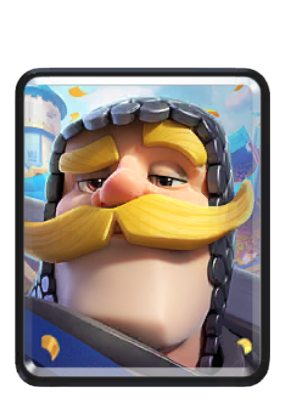

In [160]:
Image(data['items'][0]['iconUrls']['medium'], width=100)

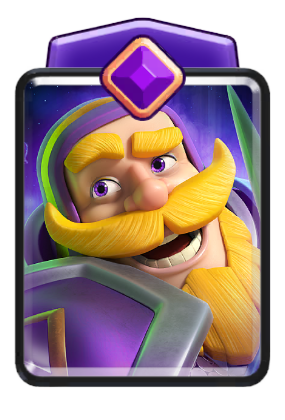

In [161]:
Image(data['items'][0]['iconUrls']['evolutionMedium'], width=100)

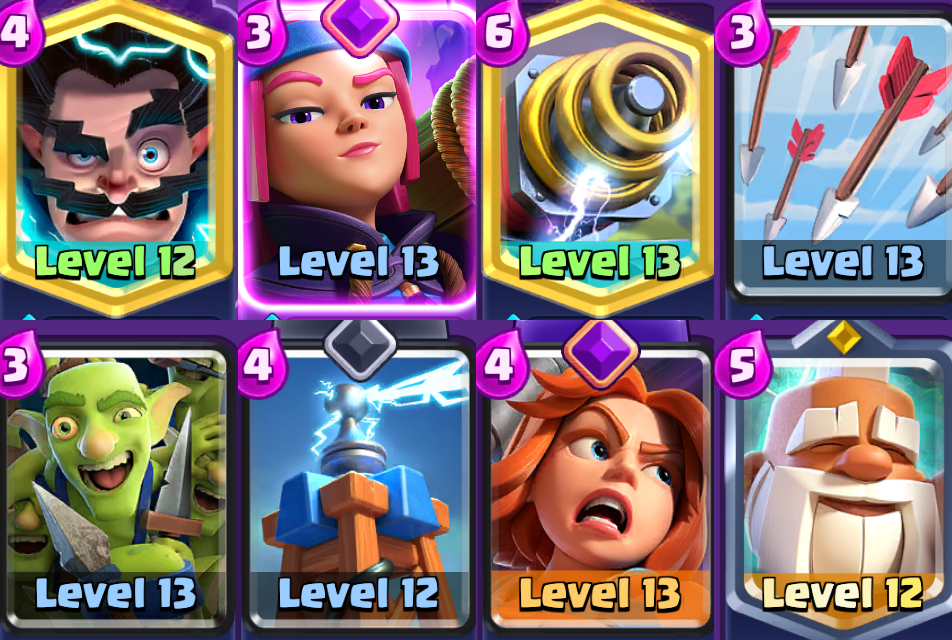

In [162]:
import cv2
import PIL
from IPython.display import display

# Load the image
img = cv2.imread("public/IMG_8557.png")

# Crop parameters
start_x = 41
width = 238
height = 320
x_gap = 40

# List to hold resized cropped images
resized_cards = []

# Extract and resize each card
for y in [667, 1110]:
    x = start_x
    for i in range(4):
        cropped = img[y:y + height, x:x + width]
        cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
        pil_img = PIL.Image.fromarray(cropped_rgb)

        resized_cards.append(pil_img)

        x += width + x_gap

# Split into two rows
row1 = resized_cards[:4]
row2 = resized_cards[4:]

# Compute dimensions
row_width = max(sum(img.width for img in row1), sum(img.width for img in row2))
row_height = max(img.height for img in row1)
total_height = row_height * 2

# Create final blank canvas
combined = PIL.Image.new("RGB", (row_width, total_height))

# Paste first row
x_offset = 0
for card in row1:
    combined.paste(card, (x_offset, 0))
    x_offset += card.width

# Paste second row
x_offset = 0
for card in row2:
    combined.paste(card, (x_offset, row_height))
    x_offset += card.width

# Display the final 2-row image
display(combined)


In [163]:
import cv2
import numpy as np

def remove_purple(img_bgr):
    # Convert to HSV for better color masking
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Define range for purple in HSV
    lower_purple = np.array([125, 50, 50])
    upper_purple = np.array([155, 255, 255])

    # Create mask for purple
    mask = cv2.inRange(hsv, lower_purple, upper_purple)

    # Invert mask to keep only non-purple areas
    mask_inv = cv2.bitwise_not(mask)

    # Apply mask: keep only non-purple pixels
    result = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_inv)
    return result

def are_images_similar(img1_pil, img2_pil, threshold=0.9):
    img1 = cv2.cvtColor(np.array(img1_pil), cv2.COLOR_RGB2BGR)
    img2 = cv2.cvtColor(np.array(img2_pil), cv2.COLOR_RGB2BGR)

    # Resize img2 to img1 size
    img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Remove purple from both images
    img1 = remove_purple(img1)
    img2 = remove_purple(img2)

    # Convert to grayscale
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Template match
    result = cv2.matchTemplate(gray1, gray2, cv2.TM_CCOEFF_NORMED)
    _, similarity, _, _ = cv2.minMaxLoc(result)

    return similarity >= threshold, similarity


In [164]:
valkyrie_item = next((item for item in data['items'] if item['name'] == 'Valkyrie'), None)
valkyrie_item

{'name': 'Valkyrie',
 'id': 26000011,
 'maxLevel': 12,
 'maxEvolutionLevel': 1,
 'elixirCost': 4,
 'iconUrls': {'medium': 'https://api-assets.clashroyale.com/cards/300/0lIoYf3Y_plFTzo95zZL93JVxpfb3MMgFDDhgSDGU9A.png',
  'evolutionMedium': 'https://api-assets.clashroyale.com/cardevolutions/300/0lIoYf3Y_plFTzo95zZL93JVxpfb3MMgFDDhgSDGU9A.png'},
 'rarity': 'rare'}

In [165]:
import requests
from io import BytesIO

url = valkyrie_item['iconUrls']['medium']
response = requests.get(url)
image = PIL.Image.open(BytesIO(response.content))


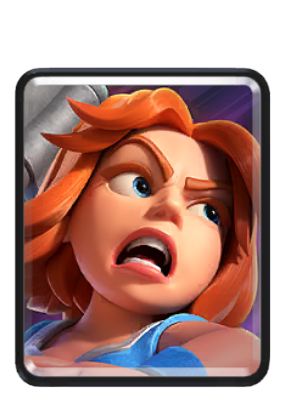

In [166]:
display(image)


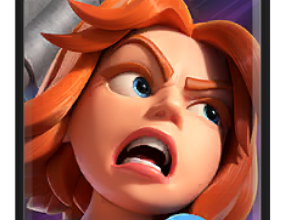

In [167]:
# Crop the image: (left, upper, right, lower)
cropped = image.crop((0, 100, 300, 320))

# Display the cropped portion
display(cropped)

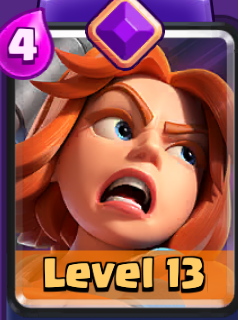

In [168]:
resized_cards[6]

In [169]:
are_images_similar(resized_cards[6], image)

(False, -0.09657411277294159)

In [170]:
for i in range(8):
    print(are_images_similar(resized_cards[i], image))

(False, -0.02486821636557579)
(False, -0.0004221469280309975)
(False, -0.15970422327518463)
(False, -0.32566913962364197)
(False, -0.22579380869865417)
(False, -0.2048252820968628)
(False, -0.09657411277294159)
(False, -0.39294126629829407)


In [171]:
are_images_similar(resized_cards[6], cropped)

(False, -0.013500724919140339)

In [172]:
for i in range(8):
    print(are_images_similar(resized_cards[i], cropped))

(False, 0.0842306986451149)
(False, 0.12187405675649643)
(False, -0.06432348489761353)
(False, -0.0888509526848793)
(False, 0.09199467301368713)
(False, -0.0637013390660286)
(False, -0.013500724919140339)
(False, -0.0934438481926918)
